## Phase 1: Run Linear Probes on Single Datasets: LLaMA-2-7B on Trivia-QA (2k)

* [Done] Variations: SE -> Acc; SE -> SE; Acc -> Acc. <br>
* [Done] Across all layers for both SLT and TBG tokens. **Goal: find best layers**. <br>
* [Done] Binarization (best split via regression forest). <br>
* [Done] Save log of test metrics for visualization.
* [Done] Take some time to alter the llama codes for keeping residuals and attention outputs.


In [1]:
%load_ext autoreload
%autoreload 2

import os
import pickle
import yaml
import json

from matplotlib import pyplot as plt
import numpy as np
import pandas as pd
import torch

from copy import deepcopy
import seaborn as sns

import wandb
os.chdir('/scratch-ssd/ms23jh/uncertainty/wandb-ref/run-20240422_125709-vjb2jtnx/files')  # path for llama2-7b on trivia_qa (2k)
# os.chdir('/scratch-ssd/ms23jh/uncertainty/wandb-ref/run-20240501_122139-p2dmjswm/files')  # path for llama2-7b on nq (3.61k) - we may take the first 2k.
# os.chdir('/scratch-ssd/ms23jh/uncertainty/wandb-ref/run-20240320_140822-qlf5m8bq/files')  # path for llama2-7b on squad (2k) - not use

Matplotlib created a temporary cache directory at /tmp/matplotlib-d3vhqtgo because the default path (/scratch-ssd/oatml/matplotlib) is not a writable directory; it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.
Matplotlib is building the font cache; this may take a moment.


## Utility Functions

In [2]:
# Read training generated embeddings
f = open('validation_generations.pkl', 'rb')
generations = pickle.load(f)
f.close()

# Read uncertainty measures (p-true, predictive/semantic uncertainties)
g = open('uncertainty_measures.pkl', 'rb')
measures = pickle.load(g)
g.close()

In [3]:
entropy = torch.tensor(measures['uncertainty_measures']['cluster_assignment_entropy']).to(torch.float32)  # replace semantic_entropy with cluster_assignment_entropy
print(entropy.shape, entropy)

torch.Size([2000]) tensor([0.3251, -0.0000, 2.0253,  ..., -0.0000, 0.8979, -0.0000])


In [4]:
# Define LR and MLP model structures (LR)
import torch
import torch.nn as nn
from torch.nn import Linear, ReLU, Dropout, BatchNorm1d, Sigmoid
from sklearn.linear_model import LogisticRegression, LinearRegression

class MLP(nn.Module):
    def __init__(self, in_dim, hid_dims, out_dim=1, dropout=0.5):
        super(MLP, self).__init__()
        layers = []
        
        if isinstance(hid_dims, int):
            layer_dims = [in_dim] + [hid_dims] * 2
        elif isinstance(hid_dims, list):
            layer_dims = [in_dim] + hid_dims
        else:
            raise ValueError("hid_dims must be either an integer or a list of integers")
        
        for i in range(len(layer_dims) - 1):
            layers.append(Linear(layer_dims[i], layer_dims[i+1]))
            layers.append(BatchNorm1d(layer_dims[i+1]))
            layers.append(ReLU())
            layers.append(Dropout(dropout))

        layers.append(Linear(layer_dims[-1], out_dim))        
        self.layers = nn.Sequential(*layers)
        
    def forward(self, x):
        return self.layers(x)


class MLPClassifier(MLP):
    def __init__(self, in_dim, hid_dims, dropout):
        super().__init__(in_dim, hid_dims, out_dim=1, dropout=dropout)

    def forward(self, x):
        x = super().forward(x)
        x = torch.sigmoid(x) 
        return x

## Use Linear Probe for Predicting Semantic Entropy 

We experiment with the 'Last Input Token before Generation' first.

In [5]:
tok_bef_gen_dataset = torch.stack([record['most_likely_answer']['emb_last_tok_before_gen'] 
                                   for record in generations.values()]).squeeze(-2).to(torch.float32)
ca_entropy = entropy.to(torch.float32)
mean = ca_entropy.mean()
std = ca_entropy.std()
print(ca_entropy.min(), ca_entropy.max(), mean, std)
ca_entropy = (ca_entropy - mean) / std

print(tok_bef_gen_dataset.shape, ca_entropy.shape)

tensor(-0.) tensor(2.3026) tensor(0.7473) tensor(0.7444)
torch.Size([2000, 33, 4096]) torch.Size([2000])


### Explore Token before First Generated Token (TBG)

We experment layer-by-layer.

In [6]:
tok_bef_gen_layered_datasets = tok_bef_gen_dataset.transpose(0, 1)
print(tok_bef_gen_layered_datasets.shape)

torch.Size([33, 2000, 4096])


In [7]:
# Make batched inputs and dataloaders (one for each layer)
from torch.utils.data import DataLoader, Subset, TensorDataset, ConcatDataset

from sklearn.model_selection import train_test_split

total_size = 2000  # Number of samples
batch_size = 32

def create_dataloaders(tok_bef_gen_layered_datasets, semantic_entropy, total_size, batch_size, set_seed=False, val_test_splits=[0.2, 0.1]):
    if set_seed:
        torch.manual_seed(42)
    
    indices = torch.randperm(total_size)
    test_size = int(total_size * val_test_splits[1])
    valid_size = int((total_size - test_size) * val_test_splits[0])
    train_size = total_size - test_size - valid_size

    train_indices = indices[:train_size]
    valid_indices = indices[train_size:train_size + valid_size]
    test_indices = indices[train_size + valid_size:]

    tbg_train_dataloaders = []
    tbg_valid_dataloaders = []
    tbg_test_dataloaders = []

    for i in range(tok_bef_gen_layered_datasets.shape[0]):
        dataset_i = tok_bef_gen_layered_datasets[i]
        
        tensor_dataset_i = TensorDataset(dataset_i, semantic_entropy)
        
        train_dataset_i = Subset(tensor_dataset_i, train_indices)
        valid_dataset_i = Subset(tensor_dataset_i, valid_indices)
        test_dataset_i = Subset(tensor_dataset_i, test_indices)
        
        train_dataloader_i = DataLoader(train_dataset_i, batch_size=batch_size, shuffle=True)
        valid_dataloader_i = DataLoader(valid_dataset_i, batch_size=batch_size, shuffle=False)
        test_dataloader_i = DataLoader(test_dataset_i, batch_size=batch_size, shuffle=False)
        
        tbg_train_dataloaders.append(train_dataloader_i)
        tbg_valid_dataloaders.append(valid_dataloader_i)
        tbg_test_dataloaders.append(test_dataloader_i)

    return tbg_train_dataloaders, tbg_valid_dataloaders, tbg_test_dataloaders
    
def create_Xs_and_ys(tok_bef_gen_layered_datasets, ca_entropy, total_size, val_test_splits=[0.2, 0.1]):
    # Data splitting for sklearn linear models
    X = tok_bef_gen_layered_datasets.numpy()
    y = ca_entropy.numpy()

    valid_size = val_test_splits[0]
    test_size = val_test_splits[1]

    X_trains = []
    X_vals = []
    X_tests = []
    y_trains = []
    y_vals = []
    y_tests = []

    for i in range(X.shape[0]):
        # Split data into train, validation, and test sets
        X_train_val, X_test, y_train_val, y_test = train_test_split(X[i], y, test_size=test_size, random_state=42)
        X_tests.append(X_test)
        y_tests.append(y_test)
        X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=valid_size, random_state=42) 
        X_trains.append(X_train)
        y_trains.append(y_train)
        X_vals.append(X_val)
        y_vals.append(y_val)

    return X_trains, X_vals, X_tests, y_trains, y_vals, y_tests

In [8]:
# Training and testing helper function.
import matplotlib.pyplot as plt
import torch.nn as nn
import torch.optim as optim

from sklearn.metrics import log_loss, roc_auc_score, mean_squared_error

# Use verbose=1 for model loss tracking.
def sklearn_train_and_evaluate(model, X_train, y_train, X_valid, y_valid, binary_cls=False, title="", silent=False):
    model.fit(X_train, y_train)
    
    # Calculate training loss and score
    if binary_cls:
        train_probs = model.predict_proba(X_train)
        train_loss = log_loss(y_train, train_probs)
    else:
        train_preds = model.predict(X_train)
        train_loss = mean_squared_error(y_train, train_preds)

    # Calculate validation loss
    valid_preds = model.predict(X_valid)
    if binary_cls:
        valid_probs = model.predict_proba(X_valid)
        valid_loss = log_loss(y_valid, valid_probs)
        val_accuracy = np.mean((valid_preds == y_valid).astype(int))
        auroc_score = roc_auc_score(y_valid, valid_probs[:,1])
        print(f"Validation Accuracy: {val_accuracy:.4f}, AUROC: {auroc_score:.4f}")
    else:
        valid_loss = mean_squared_error(y_valid, valid_preds)
        # train_score = model.score(X_train, y_train)
        # val_score = model.score(X_valid, y_valid)
        # print(f"Training R_squared: {train_score:.4f}, Validation R_squared: {val_score:.4f}")
    print(f"Training Loss: {train_loss:.4f}, Validation Loss: {valid_loss:.4f}")

def sklearn_evaluate_on_test(model, X_test, y_test, binary_cls=False):
    test_preds = model.predict(X_test)
    if binary_cls:
        test_probs = model.predict_proba(X_test)
        test_loss = log_loss(y_test, test_probs)
    else:
        test_loss = mean_squared_error(y_test, test_preds)
        
    if binary_cls:
        test_probs = test_probs[:, 1]  # Probabilities for the positive class
        test_accuracy = np.mean((test_preds == y_test).astype(int))
        auroc_score = roc_auc_score(y_test, test_probs)
        print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.4f}, AUROC: {auroc_score:.4f}")
        return test_loss, test_accuracy, auroc_score
    else:
        test_score = model.score(X_test, y_test)
        print(f"Test Loss: {test_loss:.4f}, Test R-squared: {test_score:.4f}")
        return test_loss


def train_and_evaluate(model, train_loader, valid_loader, device, criterion=nn.MSELoss(), epochs=50, 
                       binary_cls=False, title="", silent=False, lr=0.0005):
    model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    
    train_losses = []
    valid_losses = []

    for epoch in range(epochs):
        model.train()
        total_train_loss = 0
        if binary_cls:
            total_train_correct = 0
            total_train_samples = 0
            
        for inputs, scalars in train_loader:
            inputs, scalars = inputs.to(device), scalars.to(device)
            optimizer.zero_grad()
            outputs = model(inputs).squeeze()
            loss = criterion(outputs, scalars)
            loss.backward()
            optimizer.step()
            total_train_loss += loss.item()

            if binary_cls:
                preds = outputs > 0.5
                matches = preds == scalars
                total_train_correct += matches.int().sum().item()
                total_train_samples += scalars.size(0)
        
        avg_train_loss = total_train_loss / len(train_loader)
        train_losses.append(avg_train_loss)

        model.eval()
        total_valid_loss = 0
        with torch.no_grad():
            for inputs, scalars in valid_loader:
                inputs, scalars = inputs.to(device), scalars.to(device)
                outputs = model(inputs).squeeze()
                loss = criterion(outputs, scalars)
                total_valid_loss += loss.item()

        avg_valid_loss = total_valid_loss / len(valid_loader)
        valid_losses.append(avg_valid_loss)

        if epoch == 0 or (epoch+1) % 10 == 0:
            if binary_cls:
                train_accuracy = total_train_correct / total_train_samples
                print(f"Epoch {epoch+1}/{epochs}, Training Loss: {avg_train_loss:.4f}, Validation Loss: {avg_valid_loss:.4f}, Training Accuracy: {train_accuracy:.4f}")
            else:
                print(f"Epoch {epoch+1}/{epochs}, Training Loss: {avg_train_loss:.4f}, Validation Loss: {avg_valid_loss:.4f}")

    # Plot training and validation loss
    if not silent:
        plt.figure(figsize=(10, 5))
        plt.plot(train_losses, label='Training Loss')
        plt.plot(valid_losses, label='Validation Loss')
        plt.title(f'Training and Validation Losses for {title}')
        plt.xlabel('Epochs')
        plt.ylabel('Loss')
        plt.legend()
        plt.show()

    return None

def evaluate_on_test(model, test_loader, device, criterion=nn.MSELoss(), binary_cls=False):
    model.to(device)
    model.eval()
    total_test_loss = 0
    all_preds = []
    all_outputs = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs).squeeze()
            loss = criterion(outputs, labels)
            total_test_loss += loss.item()

            if binary_cls:
                preds = outputs > 0.5
                all_preds.extend(preds.cpu().numpy())
                all_outputs.extend(outputs.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())

    avg_test_loss = total_test_loss / len(test_loader)

    if binary_cls:
        test_accuracy = np.mean(np.array(all_preds) == np.array(all_labels))
        auroc_score = roc_auc_score(all_labels, all_outputs) if len(set(all_labels)) > 1 else float('nan')
        
        print(f"Test Loss: {avg_test_loss:.4f}, Test Accuracy: {test_accuracy:.4f}, AUROC: {auroc_score:.4f}")
        return avg_test_loss, test_accuracy, auroc_score
    else:
        print(f"Test Loss: {avg_test_loss:.4f}")
        return avg_test_loss

In [70]:
# Plot the 1-D pooled test losses
from datetime import datetime

def plot_1d_metrics(test_metrics_list, model_names, metric_name="MSE Losses", save_fig=False, use_logarithm=False, preset_layer_indices=None):
    plt.figure(figsize=(10, 5))
    
    # Make sure that model_names array and test_metrics_list have the same length.
    if len(test_metrics_list) != len(model_names):
        raise ValueError("The length of test_metrics_list and model_names must be the same.")
    
    for test_metrics, model_name in zip(test_metrics_list, model_names):
        test_metrics = torch.tensor(test_metrics, dtype=torch.float32)
        if use_logarithm:
            test_metrics = torch.log(test_metrics + 1e-6)
        if preset_layer_indices is not None:
            layer_indices = preset_layer_indices
        else:
            layer_indices = torch.arange(len(test_metrics)) + 1  # +1 if layer indexing starts at 1
        plt.plot(layer_indices, test_metrics, marker='o', linestyle='-', label=model_name)
    
    plt.title(f'Test {metric_name}')
    plt.xlabel('Layer_i')
    plt.ylabel(f'{metric_name}')
    plt.xticks(layer_indices) 
    plt.legend()
    plt.grid(True)
    formatted_time = datetime.now().strftime("%Y%m%d-%H%M%S")
    full_path = '~/Downloads/oatml/semantic_uncertainty/figures'
    full_path = os.path.expanduser(full_path)
    if save_fig:
        plt.savefig(f'{full_path}/test_{metric_name}_per_layer_for_{"_".join(model_names)}_{formatted_time}.jpg')
    plt.show()

def plot_metrics_w_constant(prev_best, topk_test_aucs: dict, token='TBG'):
    """
    Plots the test AUROC scores for top-k inputs alongside a horizontal line indicating
    the previous best score.
    """
    topk_test_aucs_scores = list(topk_test_aucs.values())
    x_labels = ['layer ' + ','.join(map(str, key)) for key in topk_test_aucs.keys()]
    
    # Set up the plot
    plt.figure(figsize=(10, 5)) 
    plt.plot(x_labels, topk_test_aucs_scores, label='Test AUROC for top-k Inputs', marker='o', linestyle='-')
    
    # Plot the previous best score as a horizontal line
    plt.axhline(y=prev_best, color='r', linestyle='--', label='Previous Best Test AUROC')
    
    # Adding labels and title
    plt.xlabel('Top-k Best Layers')  # Label for the X-axis
    plt.ylabel('AUROC Score')  # Label for the Y-axis
    plt.title(f'AUROC Scores for Linear Probes Trained on Concatenated Inputs from {token}') 
    plt.xticks(rotation=45)  # Rotate x-axis labels for better readability
    plt.legend()  # Add a legend to identify the lines
    
    plt.grid(True)
    
    # Display the plot
    plt.tight_layout()
    plt.show()

#### Binarize Entropy and Predict with Logistic Regression

We try binarizing the entropy scores and use logistic regression as with the accuracy prediction.

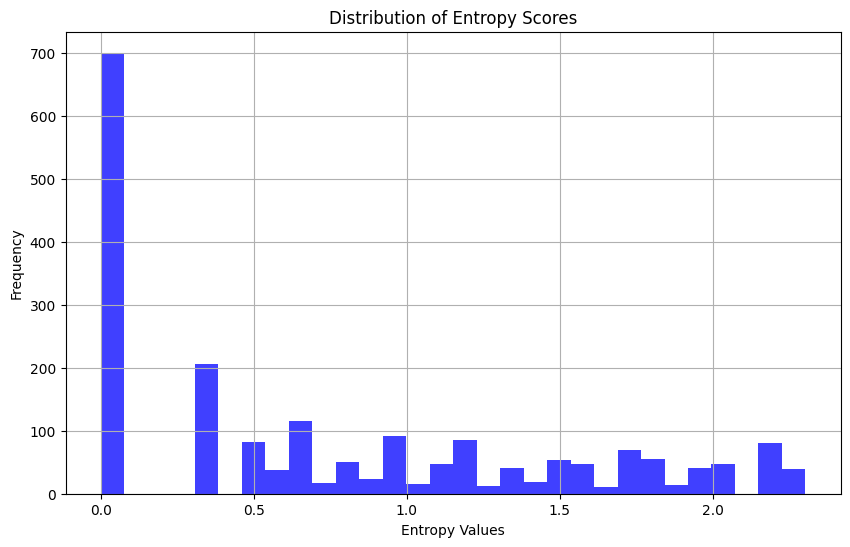

In [18]:
# Plot the entropy distribution
def plot_entropy_distribution(entropies):
    entropies_np = entropies.numpy()
    plt.figure(figsize=(10, 6))  # Set the figure size
    plt.hist(entropies_np, bins=30, alpha=0.75, color='blue')
    plt.title('Distribution of Entropy Scores')  # Title of the histogram
    plt.xlabel('Entropy Values')  # Label for the x-axis
    plt.ylabel('Frequency')  # Label for the y-axis
    plt.grid(True) 
    plt.show()

plot_entropy_distribution(entropy)

0.8140452462659786

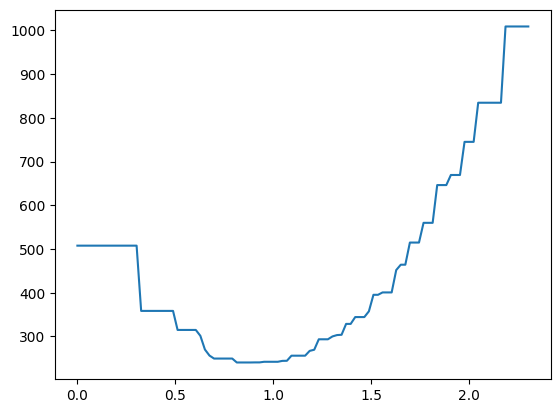

In [17]:
# Use best split approach (from Zebra notebook)
ents = entropy.numpy()
splits = np.linspace(1e-10, ents.max(), 100)
split_mses = []
for split in splits:
    low_idxs, high_idxs = ents < split, ents >= split

    low_mean = np.mean(ents[low_idxs])
    high_mean = np.mean(ents[high_idxs])

    mse = np.sum((ents[low_idxs] - low_mean)**2) + np.sum((ents[high_idxs] - high_mean)**2)
    mse = np.sum(mse)

    split_mses.append(mse)

split_mses = np.array(split_mses)

plt.plot(splits, split_mses)
splits[np.argmin(split_mses)]

In [59]:
def binarize_entropy(entropy, thres=0.0):  # 0.0 means even splits for normalized entropy scores
    """Binarize entropy scores into 0's and 1's"""
    binary_entropy = torch.full_like(entropy, -1, dtype=torch.float)
    binary_entropy[entropy < thres] = 0
    binary_entropy[entropy > thres] = 1

    return binary_entropy

# bca_entropy = binarize_entropy(entropy, splits[np.argmin(split_mses)])
bca_entropy = binarize_entropy(ca_entropy, 0.0)
print(f"Dummy accuracy: {max(torch.mean(bca_entropy).item(), 1-torch.mean(bca_entropy).item()):.4f}")

Dummy accuracy: 0.5785


In [74]:
X_trains, X_vals, X_tests, y_trains, y_vals, y_tests = create_Xs_and_ys(tok_bef_gen_layered_datasets, bca_entropy, total_size)

In [75]:
# Training with LR.
tblr_test_accs = []
tblr_test_aucs = []

for i, (X_train, X_val, X_test, y_train, y_val, y_test) in enumerate(zip(X_trains, X_vals, X_tests, y_trains, y_vals, y_tests)):
    print(f"Training on Dataset {i+1}/{len(X_trains)}")
    model = LogisticRegression()
    sklearn_train_and_evaluate(model, X_train, y_train, X_val, y_val, binary_cls=True, title=f"Logistic Regression on Dataset {i+1}")
    test_loss, test_acc, test_auc = sklearn_evaluate_on_test(model, X_test, y_test, binary_cls=True)
    tblr_test_accs.append(test_acc)
    tblr_test_aucs.append(test_auc)

Training on Dataset 1/33
Validation Accuracy: 0.5778, AUROC: 0.5195
Training Loss: 0.5799, Validation Loss: 0.6845
Test Loss: 0.6702, Test Accuracy: 0.5600, AUROC: 0.5559
Training on Dataset 2/33
Validation Accuracy: 0.5667, AUROC: 0.5584
Training Loss: 0.5340, Validation Loss: 0.6936
Test Loss: 0.6725, Test Accuracy: 0.5450, AUROC: 0.5834
Training on Dataset 3/33
Validation Accuracy: 0.5750, AUROC: 0.5734
Training Loss: 0.4557, Validation Loss: 0.7202
Test Loss: 0.6880, Test Accuracy: 0.5750, AUROC: 0.5981
Training on Dataset 4/33
Validation Accuracy: 0.6111, AUROC: 0.6152
Training Loss: 0.3981, Validation Loss: 0.7101
Test Loss: 0.6852, Test Accuracy: 0.5950, AUROC: 0.6252
Training on Dataset 5/33
Validation Accuracy: 0.6111, AUROC: 0.6271
Training Loss: 0.3548, Validation Loss: 0.7226
Test Loss: 0.6853, Test Accuracy: 0.6250, AUROC: 0.6461
Training on Dataset 6/33
Validation Accuracy: 0.6139, AUROC: 0.6412
Training Loss: 0.3088, Validation Loss: 0.7342
Test Loss: 0.7007, Test Accura

/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.6694, AUROC: 0.6862
Training Loss: 0.2092, Validation Loss: 0.7751
Test Loss: 0.6316, Test Accuracy: 0.7000, AUROC: 0.7550
Training on Dataset 9/33
Validation Accuracy: 0.6833, AUROC: 0.7044
Training Loss: 0.1791, Validation Loss: 0.7829
Test Loss: 0.6619, Test Accuracy: 0.7100, AUROC: 0.7551
Training on Dataset 10/33


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.6889, AUROC: 0.7146
Training Loss: 0.1482, Validation Loss: 0.8080
Test Loss: 0.7152, Test Accuracy: 0.6950, AUROC: 0.7571
Training on Dataset 11/33


...

/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.6972, AUROC: 0.7521
Training Loss: 0.0093, Validation Loss: 1.3520
Test Loss: 1.1468, Test Accuracy: 0.7000, AUROC: 0.8038
Training on Dataset 32/33


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.6944, AUROC: 0.7367
Training Loss: 0.0090, Validation Loss: 1.4913
Test Loss: 1.1153, Test Accuracy: 0.7250, AUROC: 0.8166
Training on Dataset 33/33
Validation Accuracy: 0.6694, AUROC: 0.7353
Training Loss: 0.0094, Validation Loss: 1.5151
Test Loss: 1.1515, Test Accuracy: 0.7550, AUROC: 0.8120


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [76]:
print(f"LR on TBG embeddings and b-SE: best AUROC {max(tblr_test_aucs):.4f} at layer {np.argmax(tblr_test_aucs)+1}")

LR on TBG embeddings and b-SE: best AUROC 0.8305 at layer 14


In [77]:
def concat_Xs_and_ys(layer_range, X_trains, X_vals, X_tests, y_trains, y_vals, y_tests):
    X_train_cc = np.concatenate(np.array(X_trains)[layer_range], axis=1)
    X_val_cc = np.concatenate(np.array(X_vals)[layer_range], axis=1)
    X_test_cc = np.concatenate(np.array(X_tests)[layer_range], axis=1)
    y_train_cc = y_trains[layer_range[0]]
    y_val_cc = y_vals[layer_range[0]]
    y_test_cc = y_tests[layer_range[0]]
    return X_train_cc, X_val_cc, X_test_cc, y_train_cc, y_val_cc, y_test_cc

In [78]:
# Save models for testing on Accuracy
tblr_best_auc_indices = np.argsort(tblr_test_aucs)[::-1]

topktblr_test_accs = {}
topktblr_test_aucs = {}
topktblr_models = {}

for top_k in range(1, 10):
    indices = tblr_best_auc_indices[:top_k]
    print(f"Training on top-{top_k} Datasets indexed", list(indices+1))
    X_train, X_val, X_test, y_train, y_val, y_test = concat_Xs_and_ys(list(indices), X_trains, X_vals, X_tests, y_trains, y_vals, y_tests)
    model = LogisticRegression()
    sklearn_train_and_evaluate(model, X_train, y_train, X_val, y_val, binary_cls=True, title=f"Logistic Regression on {top_k} Datasets")
    test_loss, test_acc, test_auc = sklearn_evaluate_on_test(model, X_test, y_test, binary_cls=True)
    topktblr_test_accs[tuple(indices)] = test_acc
    topktblr_test_aucs[tuple(indices)] = test_auc
    topktblr_models[tuple(indices)] = model

Training on top-1 Datasets indexed [14]


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.7278, AUROC: 0.7923
Training Loss: 0.0548, Validation Loss: 0.7771
Test Loss: 0.6440, Test Accuracy: 0.7350, AUROC: 0.8305
Training on top-2 Datasets indexed [14, 15]
Validation Accuracy: 0.7333, AUROC: 0.7977
Training Loss: 0.0332, Validation Loss: 0.8612
Test Loss: 0.7216, Test Accuracy: 0.7250, AUROC: 0.8303
Training on top-3 Datasets indexed [14, 15, 13]


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.7306, AUROC: 0.7941
Training Loss: 0.0273, Validation Loss: 0.9045
Test Loss: 0.7436, Test Accuracy: 0.7300, AUROC: 0.8313
Training on top-4 Datasets indexed [14, 15, 13, 32]
Validation Accuracy: 0.7139, AUROC: 0.7553
Training Loss: 0.0089, Validation Loss: 1.3996
Test Loss: 1.0309, Test Accuracy: 0.7250, AUROC: 0.8289
Training on top-5 Datasets indexed [14, 15, 13, 32, 21]


...

Validation Accuracy: 0.7056, AUROC: 0.7579
Training Loss: 0.0085, Validation Loss: 1.5848
Test Loss: 1.1243, Test Accuracy: 0.7550, AUROC: 0.8361
Training on top-8 Datasets indexed [14, 15, 13, 32, 21, 33, 22, 31]


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.7083, AUROC: 0.7612
Training Loss: 0.0084, Validation Loss: 1.6383
Test Loss: 1.2141, Test Accuracy: 0.7450, AUROC: 0.8312
Training on top-9 Datasets indexed [14, 15, 13, 32, 21, 33, 22, 31, 23]


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.6917, AUROC: 0.7585
Training Loss: 0.0084, Validation Loss: 1.6229
Test Loss: 1.1748, Test Accuracy: 0.7500, AUROC: 0.8351


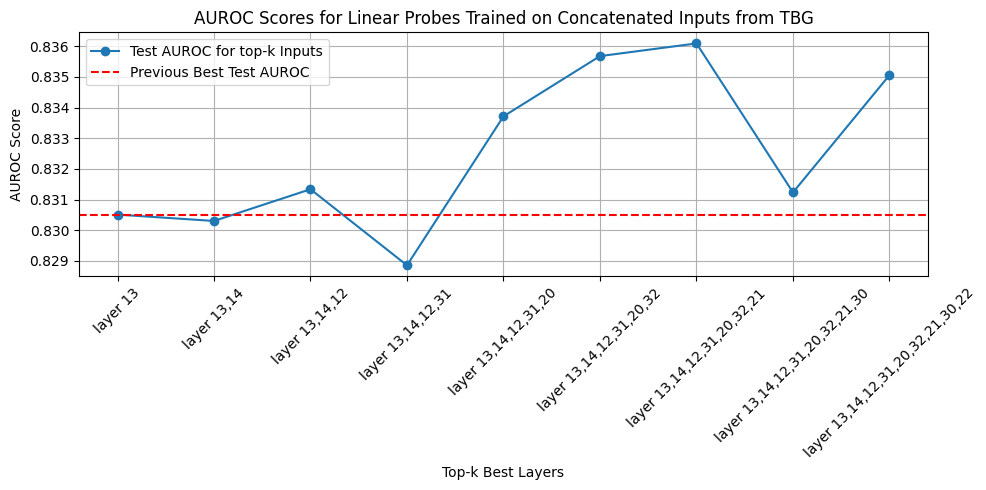

In [79]:
# Plot the concat-ed trained AUROC scores and the previous best score
plot_metrics_w_constant(max(tblr_test_aucs), topktblr_test_aucs, 'TBG')

### Explore Second Last generated Token (SLT)


In [80]:
sec_last_tok_dataset = torch.stack([record['most_likely_answer']['emb_tok_before_eos'] 
                                   for record in generations.values()]).squeeze(-2).to(torch.float32)
print(sec_last_tok_dataset.shape)

torch.Size([2000, 33, 4096])


In [26]:
sec_last_tok_dataset.transpose(0, 1).shape

torch.Size([33, 2000, 4096])

In [27]:
slt_layered_datasets = sec_last_tok_dataset.transpose(0, 1)
print(slt_layered_datasets.shape, slt_layered_datasets.dtype)

torch.Size([33, 2000, 4096]) torch.float32


In [81]:
X_trains, X_vals, X_tests, y_trains, y_vals, y_tests = create_Xs_and_ys(slt_layered_datasets, bca_entropy, total_size)

In [82]:
# Training with LR.
sblr_test_accs = []
sblr_test_aucs = []

for i, (X_train, X_val, X_test, y_train, y_val, y_test) in enumerate(zip(X_trains, X_vals, X_tests, y_trains, y_vals, y_tests)):
    print(f"Training on Dataset {i+1}/{len(X_trains)}")
    model = LogisticRegression()
    sklearn_train_and_evaluate(model, X_train, y_train, X_val, y_val, binary_cls=True, title=f"Logistic Regression on Dataset {i+1}")
    test_loss, test_acc, test_auc = sklearn_evaluate_on_test(model, X_test, y_test, binary_cls=True)
    sblr_test_accs.append(test_acc)
    sblr_test_aucs.append(test_auc)

Training on Dataset 1/33
Validation Accuracy: 0.5861, AUROC: 0.5000
Training Loss: 0.6819, Validation Loss: 0.6785
Test Loss: 0.6773, Test Accuracy: 0.5900, AUROC: 0.5000
Training on Dataset 2/33
Validation Accuracy: 0.5889, AUROC: 0.6121
Training Loss: 0.6727, Validation Loss: 0.6710
Test Loss: 0.6731, Test Accuracy: 0.5950, AUROC: 0.5588
Training on Dataset 3/33
Validation Accuracy: 0.5972, AUROC: 0.5778
Training Loss: 0.6645, Validation Loss: 0.6690
Test Loss: 0.6705, Test Accuracy: 0.5800, AUROC: 0.5653
Training on Dataset 4/33
Validation Accuracy: 0.6250, AUROC: 0.6219
Training Loss: 0.6441, Validation Loss: 0.6544
Test Loss: 0.6588, Test Accuracy: 0.6000, AUROC: 0.6068
Training on Dataset 5/33
Validation Accuracy: 0.6056, AUROC: 0.6424
Training Loss: 0.6237, Validation Loss: 0.6425
Test Loss: 0.6410, Test Accuracy: 0.6700, AUROC: 0.6519
Training on Dataset 6/33
Validation Accuracy: 0.6139, AUROC: 0.6778
Training Loss: 0.5758, Validation Loss: 0.6244
Test Loss: 0.6111, Test Accura

/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.6472, AUROC: 0.6990
Training Loss: 0.4653, Validation Loss: 0.6233
Test Loss: 0.5910, Test Accuracy: 0.6950, AUROC: 0.7376
Training on Dataset 9/33


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.6833, AUROC: 0.7237
Training Loss: 0.4213, Validation Loss: 0.6113
Test Loss: 0.5811, Test Accuracy: 0.6950, AUROC: 0.7460
Training on Dataset 10/33


...

/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.7667, AUROC: 0.8298
Training Loss: 0.0090, Validation Loss: 1.2775
Test Loss: 1.0564, Test Accuracy: 0.7650, AUROC: 0.8395
Training on Dataset 32/33


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.7583, AUROC: 0.8381
Training Loss: 0.0088, Validation Loss: 1.2647
Test Loss: 1.1947, Test Accuracy: 0.7550, AUROC: 0.8322
Training on Dataset 33/33
Validation Accuracy: 0.7750, AUROC: 0.8288
Training Loss: 0.0096, Validation Loss: 1.3051
Test Loss: 1.3091, Test Accuracy: 0.7450, AUROC: 0.8060


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [83]:
print(f"LR on SLT embeddings and b-SE: best AUROC {max(sblr_test_aucs):.4f} at layer {np.argmax(sblr_test_aucs)+1}")

LR on SLT embeddings and b-SE: best AUROC 0.8459 at layer 28


In [84]:
# Select best top-k layers 
sblr_best_auc_indices = np.argsort(sblr_test_aucs)[::-1]

topksblr_test_accs = {}
topksblr_test_aucs = {}
topksblr_models = {}

for top_k in range(1, 10):
    indices = sblr_best_auc_indices[:top_k]
    print(f"Training on top-{top_k} Datasets indexed", list(indices+1))
    X_train, X_val, X_test, y_train, y_val, y_test = concat_Xs_and_ys(list(indices), X_trains, X_vals, X_tests, y_trains, y_vals, y_tests)
    model = LogisticRegression()
    sklearn_train_and_evaluate(model, X_train, y_train, X_val, y_val, binary_cls=True, title=f"Logistic Regression on {top_k} Datasets")
    test_loss, test_acc, test_auc = sklearn_evaluate_on_test(model, X_test, y_test, binary_cls=True)
    topksblr_test_accs[tuple(indices)] = test_acc
    topksblr_test_aucs[tuple(indices)] = test_auc
    topksblr_models[tuple(indices)] = model

Training on top-1 Datasets indexed [28]


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.7194, AUROC: 0.8103
Training Loss: 0.0095, Validation Loss: 1.2813
Test Loss: 0.9793, Test Accuracy: 0.7500, AUROC: 0.8459
Training on top-2 Datasets indexed [28, 30]


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.7278, AUROC: 0.8262
Training Loss: 0.0088, Validation Loss: 1.3001
Test Loss: 1.0405, Test Accuracy: 0.7500, AUROC: 0.8488
Training on top-3 Datasets indexed [28, 30, 31]


...

/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.7639, AUROC: 0.8393
Training Loss: 0.0083, Validation Loss: 1.4918
Test Loss: 1.2503, Test Accuracy: 0.7650, AUROC: 0.8539
Training on top-8 Datasets indexed [28, 30, 31, 29, 22, 32, 21, 16]


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.7611, AUROC: 0.8402
Training Loss: 0.0083, Validation Loss: 1.5136
Test Loss: 1.2688, Test Accuracy: 0.7650, AUROC: 0.8533
Training on top-9 Datasets indexed [28, 30, 31, 29, 22, 32, 21, 16, 12]
Validation Accuracy: 0.7667, AUROC: 0.8417
Training Loss: 0.0084, Validation Loss: 1.4877
Test Loss: 1.2571, Test Accuracy: 0.7700, AUROC: 0.8541


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


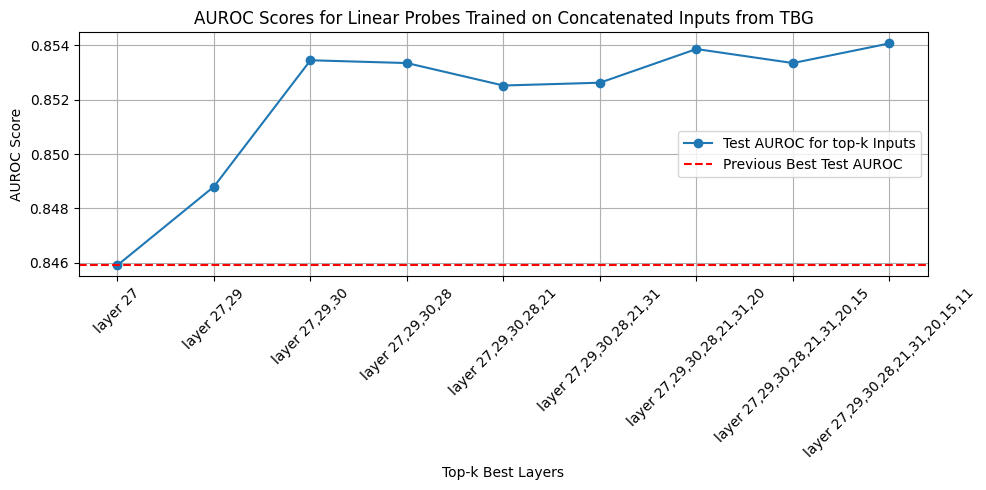

In [85]:
# Plot the concat-ed trained AUROC scores and the previous best score
plot_metrics_w_constant(max(sblr_test_aucs), topksblr_test_aucs, 'TBG')

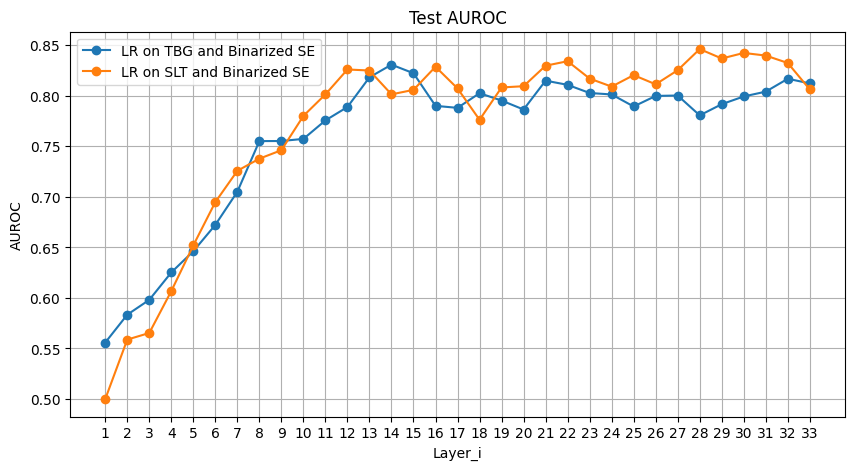

TBG: max AUROC for LR trained and tested on Binarized SE: 0.8305 at 14 layer
SLT: max AUROC for LR trained and tested on Binarized SE: 0.8459 at 28 layer


In [97]:
plot_1d_metrics([tblr_test_aucs, sblr_test_aucs], ['LR on TBG and Binarized SE', 'LR on SLT and Binarized SE'], 'AUROC')
print(f"TBG: max AUROC for LR trained and tested on Binarized SE: {max(tblr_test_aucs):.4f} at {np.argmax(tblr_test_aucs)+1} layer")
print(f"SLT: max AUROC for LR trained and tested on Binarized SE: {max(sblr_test_aucs):.4f} at {np.argmax(sblr_test_aucs)+1} layer")

## Use Linear Probe for Predicting Correctness of Generated Answers (or Accuracy)

It would be interesting to see how linear probes perform at predicting accuracy obtained from using semantic entropy at selecting the most probable answer (true or false), as indicated in the `compute_uncertainty_measures.py` (_# For the semantic uncertainties, we can also change the prediction, by first selecting the semantic cluster with the highest probability, and then selecting the generation with the highest probability within that cluster._)

We will use logistic regression for this task, as for the binarized entropy prediction task.

### Token Before first Generation (TBG)

In [32]:
accuracies = torch.tensor([record['most_likely_answer']['accuracy'] for record in generations.values()])
print(accuracies.shape, accuracies[:10])  # "Accuracies" are binary. Classification task.

torch.Size([2000]) tensor([1., 1., 0., 1., 0., 0., 1., 0., 1., 0.])


In [33]:
# Prepare X's and y's for sklearn LR model.
X_trains, X_vals, X_tests, y_trains, y_vals, y_tests = create_Xs_and_ys(tok_bef_gen_layered_datasets, accuracies, total_size)

In [34]:
# Dummy accuracy:
print(f"Dummy accuracy: {max(np.mean(y_tests), 1-np.mean(y_tests)):.4f}")

Dummy accuracy: 0.6250


In [35]:
# Training Loops (LR)
talr_test_accs = []
talr_test_aucs = []

for i, (X_train, X_val, X_test, y_train, y_val, y_test) in enumerate(zip(X_trains, X_vals, X_tests, y_trains, y_vals, y_tests)):
    print(f"Training on TBG-Acc Dataset {i+1}/{len(X_trains)}")
    model = LogisticRegression()
    sklearn_train_and_evaluate(model, X_train, y_train, X_val, y_val, binary_cls=True, title=f"Logistic Regression on TBG-Acc Dataset {i+1}")
    test_loss, test_acc, test_auc = sklearn_evaluate_on_test(model, X_test, y_test, binary_cls=True)
    talr_test_accs.append(test_acc)
    talr_test_aucs.append(test_auc)

Training on TBG-Acc Dataset 1/33
Validation Accuracy: 0.6639, AUROC: 0.5158
Training Loss: 0.5520, Validation Loss: 0.6365
Test Loss: 0.6232, Test Accuracy: 0.6700, AUROC: 0.6665
Training on TBG-Acc Dataset 2/33
Validation Accuracy: 0.6583, AUROC: 0.5278
Training Loss: 0.5098, Validation Loss: 0.6460
Test Loss: 0.6051, Test Accuracy: 0.6800, AUROC: 0.7005
Training on TBG-Acc Dataset 3/33
Validation Accuracy: 0.6611, AUROC: 0.5678
Training Loss: 0.4350, Validation Loss: 0.6539
Test Loss: 0.6088, Test Accuracy: 0.6450, AUROC: 0.6835
Training on TBG-Acc Dataset 4/33
Validation Accuracy: 0.6500, AUROC: 0.5945
Training Loss: 0.3778, Validation Loss: 0.6605
Test Loss: 0.6356, Test Accuracy: 0.6650, AUROC: 0.6721
Training on TBG-Acc Dataset 5/33
Validation Accuracy: 0.6444, AUROC: 0.5877
Training Loss: 0.3379, Validation Loss: 0.6942
Test Loss: 0.6577, Test Accuracy: 0.6600, AUROC: 0.6726
Training on TBG-Acc Dataset 6/33


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.6278, AUROC: 0.5708
Training Loss: 0.3005, Validation Loss: 0.7449
Test Loss: 0.7133, Test Accuracy: 0.6200, AUROC: 0.6630
Training on TBG-Acc Dataset 7/33


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.6361, AUROC: 0.6086
Training Loss: 0.2579, Validation Loss: 0.7243
Test Loss: 0.6845, Test Accuracy: 0.6800, AUROC: 0.6930
Training on TBG-Acc Dataset 8/33


...

/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.6917, AUROC: 0.7120
Training Loss: 0.0295, Validation Loss: 0.9862
Test Loss: 0.8032, Test Accuracy: 0.7850, AUROC: 0.7885
Training on TBG-Acc Dataset 18/33
Validation Accuracy: 0.7111, AUROC: 0.7238
Training Loss: 0.0189, Validation Loss: 1.0420
Test Loss: 0.8427, Test Accuracy: 0.7750, AUROC: 0.7914
Training on TBG-Acc Dataset 19/33


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.6833, AUROC: 0.6845
Training Loss: 0.0142, Validation Loss: 1.2383
Test Loss: 0.9108, Test Accuracy: 0.7300, AUROC: 0.7863
Training on TBG-Acc Dataset 20/33
Validation Accuracy: 0.7167, AUROC: 0.6880
Training Loss: 0.0113, Validation Loss: 1.2805
Test Loss: 0.8772, Test Accuracy: 0.7700, AUROC: 0.8013
Training on TBG-Acc Dataset 21/33
Validation Accuracy: 0.7056, AUROC: 0.6708
Training Loss: 0.0085, Validation Loss: 1.3457
Test Loss: 0.9690, Test Accuracy: 0.7500, AUROC: 0.7858
Training on TBG-Acc Dataset 22/33
Validation Accuracy: 0.7111, AUROC: 0.6895
Training Loss: 0.0061, Validation Loss: 1.3378
Test Loss: 1.0762, Test Accuracy: 0.7300, AUROC: 0.7772
Training on TBG-Acc Dataset 23/33
Validation Accuracy: 0.7056, AUROC: 0.7003
Training Loss: 0.0049, Validation Loss: 1.3012
Test Loss: 1.1039, Test Accuracy: 0.7350, AUROC: 0.7750
Training on TBG-Acc Dataset 24/33
Validation Accuracy: 0.7194, AUROC: 0.7034
Training Loss: 0.0040, Validation Loss: 1.2886
Test Loss:

KeyboardInterrupt: 

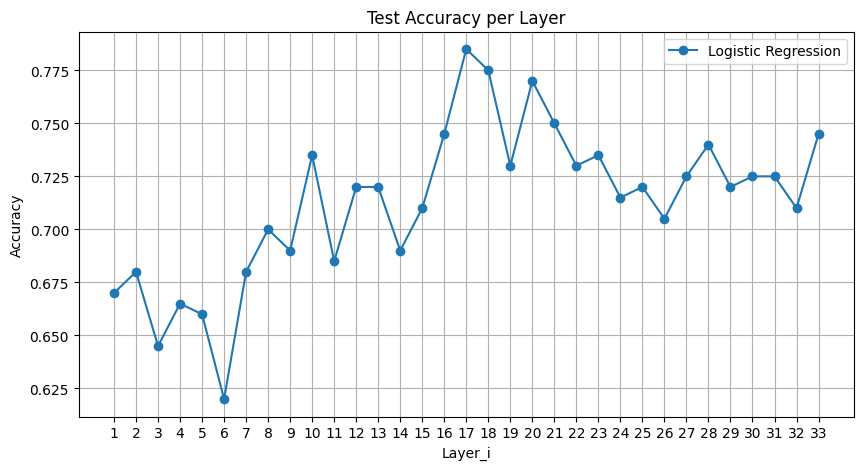

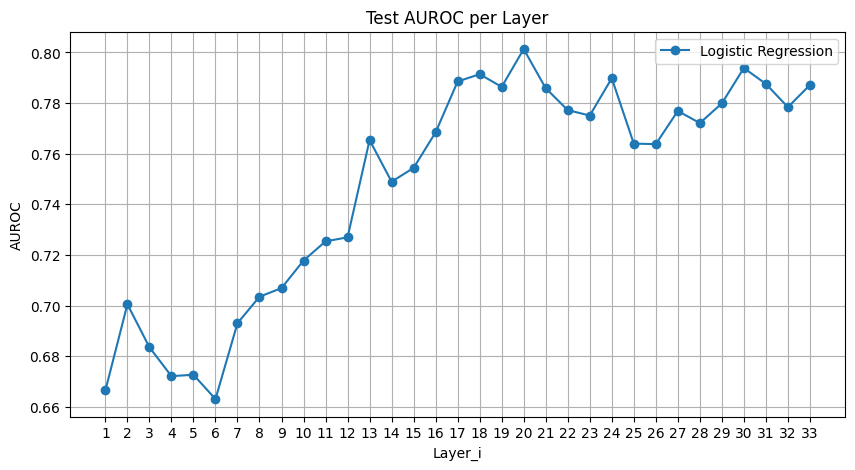

In [55]:
plot_1d_metrics([talr_test_accs], ['Logistic Regression'], 'Accuracy')
plot_1d_metrics([talr_test_aucs], ['Logistic Regression'], 'AUROC')

In [56]:
print(f"LR on TBG embeddings and Accuracy: best AUROC {max(talr_test_aucs):.4f} at layer {np.argmax(talr_test_aucs)+1}")

LR on TBG embeddings and Accuracy: best AUROC 0.8013 at layer 20


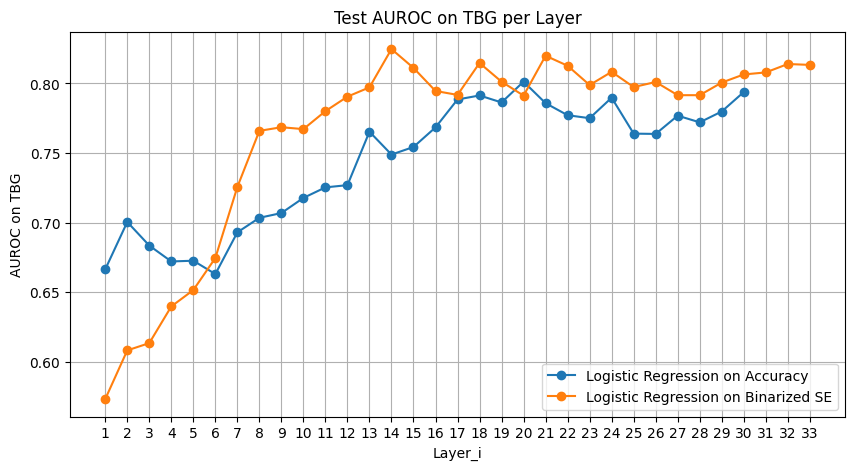

TBG: max AUROC for LR trained on Accuracy, tested on Accuracy: 0.8013 at 20 layer
TBG: max AUROC for LR trained on Binary SE, tested on Binary SE: 0.8247 at 14 layer


In [54]:
plot_1d_metrics([talr_test_aucs, tblr_test_aucs], ['Logistic Regression on Accuracy', 'Logistic Regression on Binarized SE'], 'AUROC on TBG')
print(f"TBG: max AUROC for LR trained on Accuracy, tested on Accuracy: {max(talr_test_aucs):.4f} at {np.argmax(talr_test_aucs)+1} layer")
print(f"TBG: max AUROC for LR trained on Binary SE, tested on Binary SE: {max(tblr_test_aucs):.4f} at {np.argmax(tblr_test_aucs)+1} layer")

In [46]:
# Data for SLT embeddings
X_trains, X_vals, X_tests, y_trains, y_vals, y_tests = create_Xs_and_ys(slt_layered_datasets, accuracies, total_size)

In [47]:
# Training with LR.
salr_test_accs = []
salr_test_aucs = []

for i, (X_train, X_val, X_test, y_train, y_val, y_test) in enumerate(zip(X_trains, X_vals, X_tests, y_trains, y_vals, y_tests)):
    print(f"Training on SLT-Acc Dataset {i+1}/{len(X_trains)}")
    model = LogisticRegression()
    sklearn_train_and_evaluate(model, X_train, y_train, X_val, y_val, binary_cls=True, title=f"Logistic Regression on SLT-Acc Dataset {i+1}")
    test_loss, test_acc, test_auc = sklearn_evaluate_on_test(model, X_test, y_test, binary_cls=True)
    salr_test_accs.append(test_acc)
    salr_test_aucs.append(test_auc)

Training on SLT-Acc Dataset 1/33
Validation Accuracy: 0.6750, AUROC: 0.5000
Training Loss: 0.6500, Validation Loss: 0.6325
Test Loss: 0.6625, Test Accuracy: 0.6250, AUROC: 0.5000
Training on SLT-Acc Dataset 2/33
Validation Accuracy: 0.6750, AUROC: 0.5260
Training Loss: 0.6418, Validation Loss: 0.6296
Test Loss: 0.6586, Test Accuracy: 0.6250, AUROC: 0.5854
Training on SLT-Acc Dataset 3/33
Validation Accuracy: 0.6750, AUROC: 0.5365
Training Loss: 0.6363, Validation Loss: 0.6278
Test Loss: 0.6569, Test Accuracy: 0.6250, AUROC: 0.5854
Training on SLT-Acc Dataset 4/33
Validation Accuracy: 0.6806, AUROC: 0.5851
Training Loss: 0.6211, Validation Loss: 0.6200
Test Loss: 0.6554, Test Accuracy: 0.6200, AUROC: 0.5707
Training on SLT-Acc Dataset 5/33
Validation Accuracy: 0.6833, AUROC: 0.6016
Training Loss: 0.6086, Validation Loss: 0.6144
Test Loss: 0.6486, Test Accuracy: 0.6300, AUROC: 0.5939
Training on SLT-Acc Dataset 6/33
Validation Accuracy: 0.6861, AUROC: 0.6098
Training Loss: 0.5703, Valida

/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.6667, AUROC: 0.6430
Training Loss: 0.5342, Validation Loss: 0.6019
Test Loss: 0.6203, Test Accuracy: 0.6800, AUROC: 0.6640
Training on SLT-Acc Dataset 8/33
Validation Accuracy: 0.6778, AUROC: 0.6666
Training Loss: 0.4737, Validation Loss: 0.5984
Test Loss: 0.6193, Test Accuracy: 0.6700, AUROC: 0.6729
Training on SLT-Acc Dataset 9/33


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.6944, AUROC: 0.6943
Training Loss: 0.4289, Validation Loss: 0.5838
Test Loss: 0.5890, Test Accuracy: 0.6800, AUROC: 0.7126
Training on SLT-Acc Dataset 10/33


...

/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.7611, AUROC: 0.7970
Training Loss: 0.0324, Validation Loss: 0.7893
Test Loss: 0.8308, Test Accuracy: 0.7450, AUROC: 0.7886
Training on SLT-Acc Dataset 19/33
Validation Accuracy: 0.7778, AUROC: 0.7866
Training Loss: 0.0238, Validation Loss: 0.8204
Test Loss: 0.9743, Test Accuracy: 0.7350, AUROC: 0.7626
Training on SLT-Acc Dataset 20/33


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.7556, AUROC: 0.7684
Training Loss: 0.0185, Validation Loss: 0.9419
Test Loss: 1.0492, Test Accuracy: 0.7750, AUROC: 0.7742
Training on SLT-Acc Dataset 21/33
Validation Accuracy: 0.7278, AUROC: 0.7482
Training Loss: 0.0127, Validation Loss: 1.0475
Test Loss: 0.9388, Test Accuracy: 0.7600, AUROC: 0.7868
Training on SLT-Acc Dataset 22/33
Validation Accuracy: 0.7028, AUROC: 0.7097
Training Loss: 0.0082, Validation Loss: 1.3923
Test Loss: 1.1712, Test Accuracy: 0.7300, AUROC: 0.7654
Training on SLT-Acc Dataset 23/33
Validation Accuracy: 0.7000, AUROC: 0.7234
Training Loss: 0.0061, Validation Loss: 1.4137
Test Loss: 1.3273, Test Accuracy: 0.7550, AUROC: 0.7537
Training on SLT-Acc Dataset 24/33
Validation Accuracy: 0.7194, AUROC: 0.7570
Training Loss: 0.0048, Validation Loss: 1.2491
Test Loss: 1.3174, Test Accuracy: 0.7550, AUROC: 0.7700
Training on SLT-Acc Dataset 25/33
Validation Accuracy: 0.7139, AUROC: 0.7557
Training Loss: 0.0040, Validation Loss: 1.2427
Test Loss:

/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


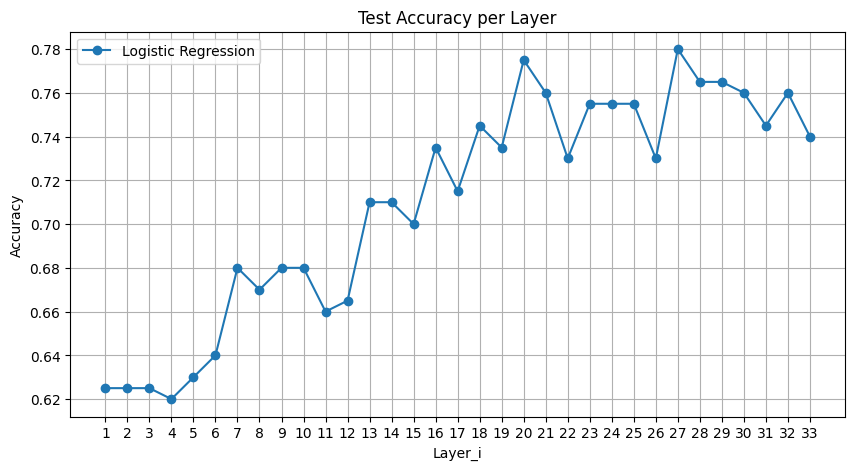

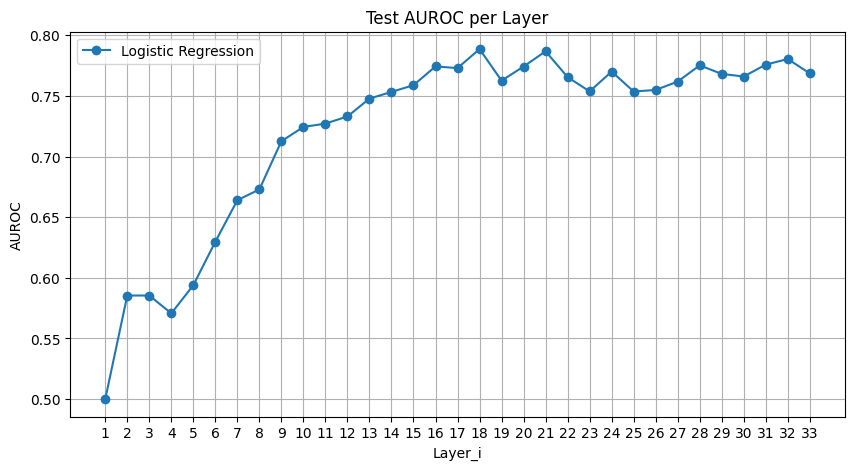

In [48]:
plot_1d_metrics([salr_test_accs], ['Logistic Regression'], 'Accuracy')
plot_1d_metrics([salr_test_aucs], ['Logistic Regression'], 'AUROC')

In [49]:
print(f"LR on SLT embeddings and Accuracy: best AUROC {max(salr_test_aucs):.4f} at layer {np.argmax(salr_test_aucs)+1}")

LR on SLT embeddings and Accuracy: best AUROC 0.7886 at layer 18


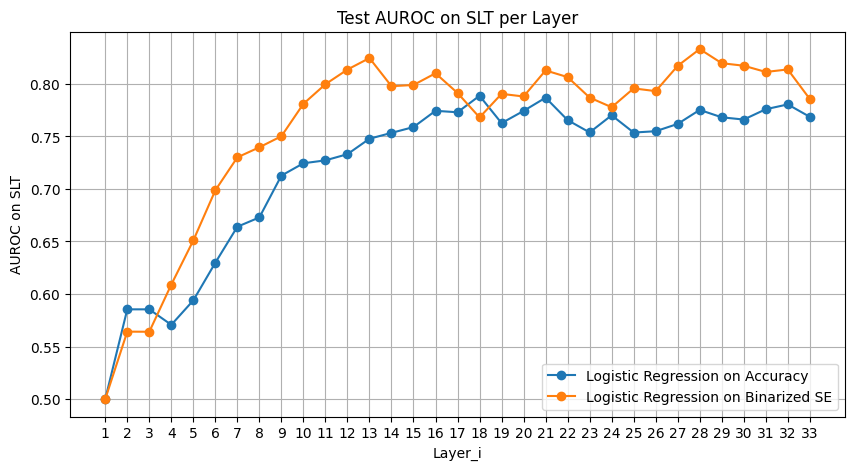

SLT: max AUROC for LR trained on Accuracy, tested on Accuracy: 0.7886 at 18 layer
SLT: max AUROC for LR trained on Binary SE, tested on Binary SE: 0.8330 at 28 layer


In [55]:
plot_1d_metrics([salr_test_aucs, sblr_test_aucs], ['Logistic Regression on Accuracy', 'Logistic Regression on Binarized SE'], 'AUROC on SLT')
print(f"SLT: max AUROC for LR trained on Accuracy, tested on Accuracy: {max(salr_test_aucs):.4f} at {np.argmax(salr_test_aucs)+1} layer")
print(f"SLT: max AUROC for LR trained on Binary SE, tested on Binary SE: {max(sblr_test_aucs):.4f} at {np.argmax(sblr_test_aucs)+1} layer")

## Use Classifier for Binary SE for Predicting LLM Accuracy

We want to show that models trained on binary SE are more generalizable to new datasets when predicting their generation correctness.

In [86]:
# Test with accuracy test set (with the same random seed to ensure no data leakage)
# We should reverse the accuracy due to negative R.
r_accuracies = 1 - accuracies

X_trains, X_vals, _, y_trains, y_vals, _ = create_Xs_and_ys(tok_bef_gen_layered_datasets, bca_entropy, total_size)
_, _, X_tests, _, _, y_tests = create_Xs_and_ys(tok_bef_gen_layered_datasets, r_accuracies, total_size)

In [89]:
# Training Loops (LR)
tablr_test_accs = []
tablr_test_aucs = []
tablr_trained_models = []

for i, (X_train, X_val, X_test, y_train, y_val, y_test) in enumerate(zip(X_trains, X_vals, X_tests, y_trains, y_vals, y_tests)):
    print(f"Training on TBG Dataset {i+1}/{len(X_trains)}")
    model = LogisticRegression()
    sklearn_train_and_evaluate(model, X_train, y_train, X_val, y_val, binary_cls=True, title=f"Logistic Regression on TBG Dataset {i+1}")
    test_loss, test_acc, test_auc = sklearn_evaluate_on_test(model, X_test, y_test, binary_cls=True)
    tablr_test_accs.append(test_acc)
    tablr_test_aucs.append(test_auc)
    tablr_trained_models.append(model)

Training on TBG Dataset 1/33
Validation Accuracy: 0.5778, AUROC: 0.5195
Training Loss: 0.5799, Validation Loss: 0.6845
Test Loss: 0.6609, Test Accuracy: 0.5750, AUROC: 0.5324
Training on TBG Dataset 2/33
Validation Accuracy: 0.5667, AUROC: 0.5584
Training Loss: 0.5340, Validation Loss: 0.6936
Test Loss: 0.6758, Test Accuracy: 0.5600, AUROC: 0.5392
Training on TBG Dataset 3/33
Validation Accuracy: 0.5750, AUROC: 0.5734
Training Loss: 0.4557, Validation Loss: 0.7202
Test Loss: 0.6950, Test Accuracy: 0.5900, AUROC: 0.5795
Training on TBG Dataset 4/33
Validation Accuracy: 0.6111, AUROC: 0.6152
Training Loss: 0.3981, Validation Loss: 0.7101
Test Loss: 0.7049, Test Accuracy: 0.6000, AUROC: 0.5979
Training on TBG Dataset 5/33
Validation Accuracy: 0.6111, AUROC: 0.6271
Training Loss: 0.3548, Validation Loss: 0.7226
Test Loss: 0.7313, Test Accuracy: 0.6100, AUROC: 0.5991
Training on TBG Dataset 6/33
Validation Accuracy: 0.6139, AUROC: 0.6412
Training Loss: 0.3088, Validation Loss: 0.7342
Test L

/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.6694, AUROC: 0.6862
Training Loss: 0.2092, Validation Loss: 0.7751
Test Loss: 0.7645, Test Accuracy: 0.6550, AUROC: 0.6611
Training on TBG Dataset 9/33
Validation Accuracy: 0.6833, AUROC: 0.7044
Training Loss: 0.1791, Validation Loss: 0.7829
Test Loss: 0.8377, Test Accuracy: 0.6450, AUROC: 0.6643
Training on TBG Dataset 10/33


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.6889, AUROC: 0.7146
Training Loss: 0.1482, Validation Loss: 0.8080
Test Loss: 0.8795, Test Accuracy: 0.6600, AUROC: 0.6738
Training on TBG Dataset 11/33


...

/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.6972, AUROC: 0.7521
Training Loss: 0.0093, Validation Loss: 1.3520
Test Loss: 1.7248, Test Accuracy: 0.6650, AUROC: 0.7162
Training on TBG Dataset 32/33


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.6944, AUROC: 0.7367
Training Loss: 0.0090, Validation Loss: 1.4913
Test Loss: 1.8068, Test Accuracy: 0.6500, AUROC: 0.7156
Training on TBG Dataset 33/33
Validation Accuracy: 0.6694, AUROC: 0.7353
Training Loss: 0.0094, Validation Loss: 1.5151
Test Loss: 1.7032, Test Accuracy: 0.7100, AUROC: 0.7403


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


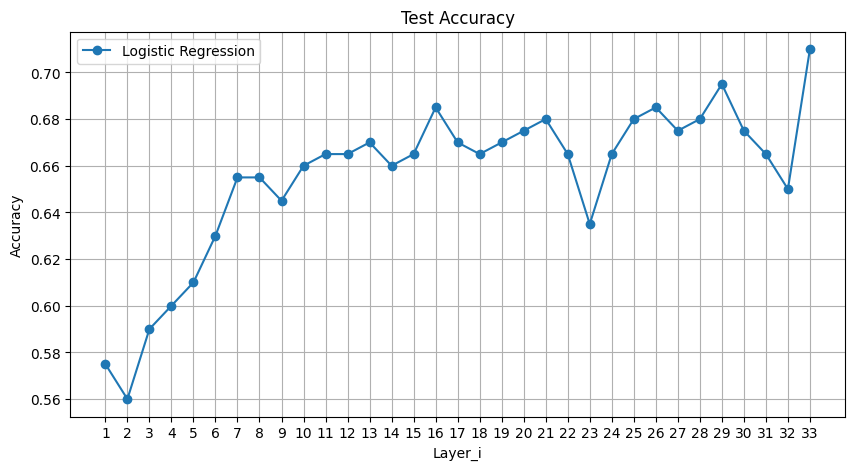

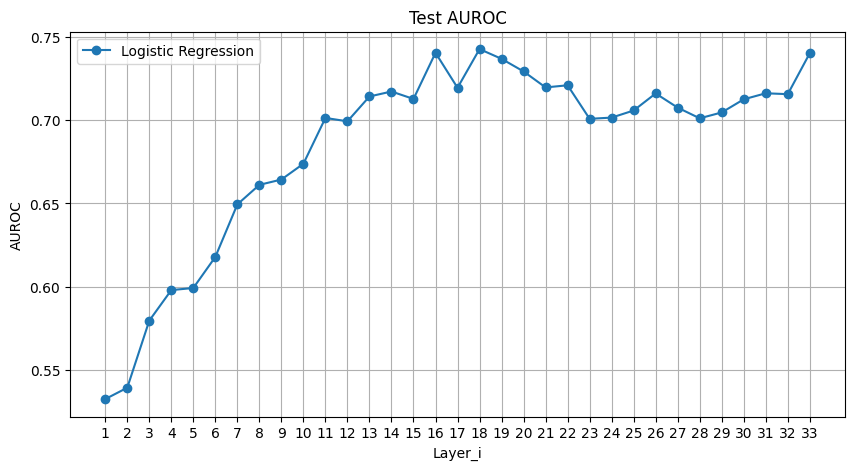

In [90]:
plot_1d_metrics([tablr_test_accs], ['Logistic Regression'], 'Accuracy')
plot_1d_metrics([tablr_test_aucs], ['Logistic Regression'], 'AUROC')

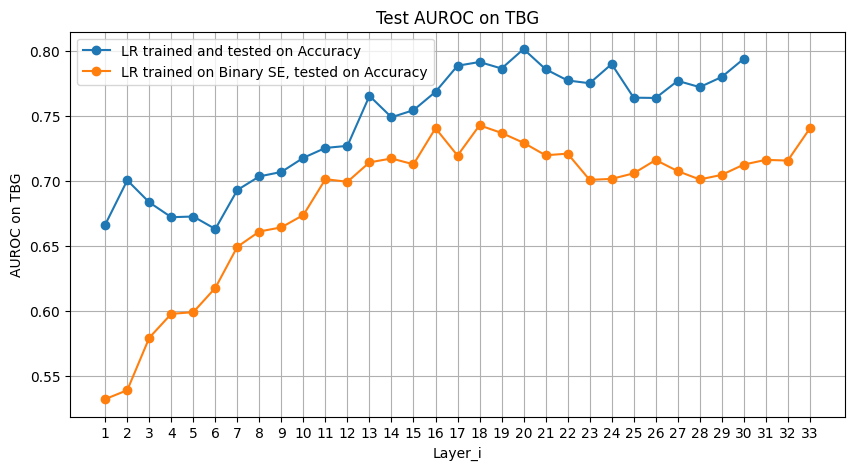

TBG: max AUROC for LR trained on Accuracy, tested on Accuracy: 0.8013 at 20 layer
TBG: max AUROC for LR trained on Binary SE, tested on Accuracy: 0.7427 at 18 layer


In [91]:
# Max AUROC achieved by 'transfer learning' compared to normal training
plot_1d_metrics([talr_test_aucs, tablr_test_aucs], ['LR trained and tested on Accuracy', 'LR trained on Binary SE, tested on Accuracy'], 'AUROC on TBG')
print(f"TBG: max AUROC for LR trained on Accuracy, tested on Accuracy: {max(talr_test_aucs):.4f} at {np.argmax(talr_test_aucs)+1} layer")
print(f"TBG: max AUROC for LR trained on Binary SE, tested on Accuracy: {max(tablr_test_aucs):.4f} at {np.argmax(tablr_test_aucs)+1} layer")

In [87]:
## Use trained probes on concat-ed inputs of best layers
topktablr_test_accs = {}
topktablr_test_aucs = {}

for indices in topktblr_models.keys():
    print(f"Testing on top-{len(indices)} TBG Datasets trained probe:", list(indices))
    _, _, X_test, _, _, y_test = concat_Xs_and_ys(list(indices), X_trains, X_vals, X_tests, y_trains, y_vals, y_tests)
    model = topktblr_models[indices]
    test_loss, test_acc, test_auc = sklearn_evaluate_on_test(model, X_test, y_test, binary_cls=True)
    topktablr_test_accs[tuple(indices)] = test_acc
    topktablr_test_aucs[tuple(indices)] = test_auc

Testing on top-1 TBG Datasets trained probe: [13]
Test Loss: 1.0179, Test Accuracy: 0.6600, AUROC: 0.7172
Testing on top-2 TBG Datasets trained probe: [13, 14]
Test Loss: 1.1629, Test Accuracy: 0.6600, AUROC: 0.7204
Testing on top-3 TBG Datasets trained probe: [13, 14, 12]
Test Loss: 1.1979, Test Accuracy: 0.6650, AUROC: 0.7202
Testing on top-4 TBG Datasets trained probe: [13, 14, 12, 31]
Test Loss: 1.7087, Test Accuracy: 0.6600, AUROC: 0.7294
Testing on top-5 TBG Datasets trained probe: [13, 14, 12, 31, 20]
Test Loss: 1.7118, Test Accuracy: 0.6900, AUROC: 0.7325
Testing on top-6 TBG Datasets trained probe: [13, 14, 12, 31, 20, 32]
Test Loss: 1.7477, Test Accuracy: 0.6750, AUROC: 0.7476
Testing on top-7 TBG Datasets trained probe: [13, 14, 12, 31, 20, 32, 21]
Test Loss: 1.8400, Test Accuracy: 0.7000, AUROC: 0.7458
Testing on top-8 TBG Datasets trained probe: [13, 14, 12, 31, 20, 32, 21, 30]
Test Loss: 1.9483, Test Accuracy: 0.6900, AUROC: 0.7425
Testing on top-9 TBG Datasets trained pr

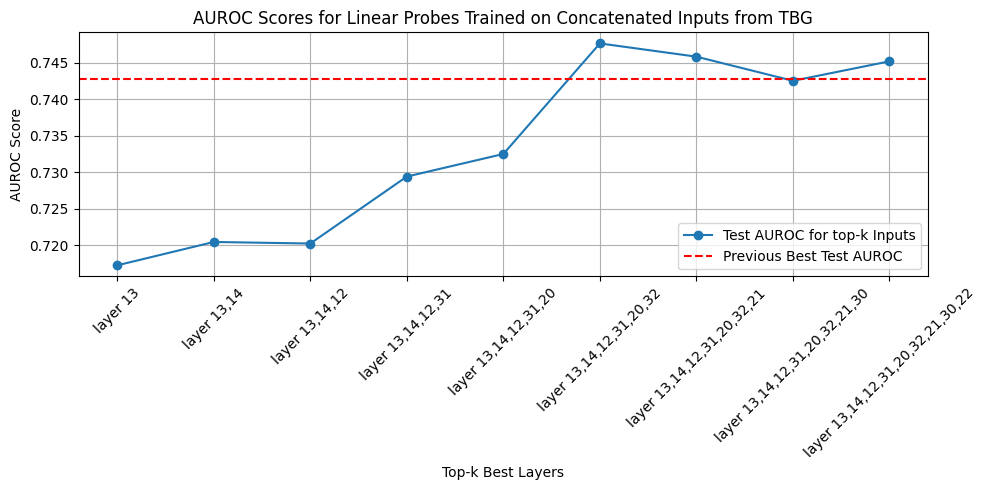

In [92]:
plot_metrics_w_constant(max(tablr_test_aucs), topktablr_test_aucs, 'TBG')

Now we test on SLT embeddings.

In [93]:
X_trains, X_vals, _, y_trains, y_vals, _ = create_Xs_and_ys(slt_layered_datasets, bca_entropy, total_size)
_, _, X_tests, _, _, y_tests = create_Xs_and_ys(slt_layered_datasets, r_accuracies, total_size)

In [67]:
# Training Loops (LR)
sablr_test_accs = []
sablr_test_aucs = []
sablr_trained_models = []

for i, (X_train, X_val, X_test, y_train, y_val, y_test) in enumerate(zip(X_trains, X_vals, X_tests, y_trains, y_vals, y_tests)):
    print(f"Training on SLT Dataset {i+1}/{len(X_trains)}")
    model = LogisticRegression()
    sklearn_train_and_evaluate(model, X_train, y_train, X_val, y_val, binary_cls=True, title=f"Logistic Regression on SLT Dataset {i+1}")
    test_loss, test_acc, test_auc = sklearn_evaluate_on_test(model, X_test, y_test, binary_cls=True)
    sablr_test_accs.append(test_acc)
    sablr_test_aucs.append(test_auc)
    sablr_trained_models.append(model)

Training on SLT Dataset 1/33
Validation Accuracy: 0.5861, AUROC: 0.5000
Training Loss: 0.6819, Validation Loss: 0.6785
Test Loss: 0.6668, Test Accuracy: 0.6250, AUROC: 0.5000
Training on SLT Dataset 2/33
Validation Accuracy: 0.5889, AUROC: 0.6121
Training Loss: 0.6727, Validation Loss: 0.6710
Test Loss: 0.6682, Test Accuracy: 0.6300, AUROC: 0.4971
Training on SLT Dataset 3/33
Validation Accuracy: 0.5972, AUROC: 0.5778
Training Loss: 0.6645, Validation Loss: 0.6690
Test Loss: 0.6677, Test Accuracy: 0.6150, AUROC: 0.5035
Training on SLT Dataset 4/33
Validation Accuracy: 0.6250, AUROC: 0.6219
Training Loss: 0.6441, Validation Loss: 0.6544
Test Loss: 0.6668, Test Accuracy: 0.5950, AUROC: 0.5437
Training on SLT Dataset 5/33
Validation Accuracy: 0.6056, AUROC: 0.6424
Training Loss: 0.6237, Validation Loss: 0.6425
Test Loss: 0.6512, Test Accuracy: 0.6350, AUROC: 0.6027
Training on SLT Dataset 6/33
Validation Accuracy: 0.6139, AUROC: 0.6778
Training Loss: 0.5758, Validation Loss: 0.6244
Test L

/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.6472, AUROC: 0.6990
Training Loss: 0.4653, Validation Loss: 0.6233
Test Loss: 0.6305, Test Accuracy: 0.6800, AUROC: 0.6858
Training on SLT Dataset 9/33


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.6833, AUROC: 0.7237
Training Loss: 0.4213, Validation Loss: 0.6113
Test Loss: 0.6149, Test Accuracy: 0.6700, AUROC: 0.7021
Training on SLT Dataset 10/33


...

/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.7667, AUROC: 0.8298
Training Loss: 0.0090, Validation Loss: 1.2775
Test Loss: 1.6703, Test Accuracy: 0.6800, AUROC: 0.7506
Training on SLT Dataset 32/33


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.7583, AUROC: 0.8381
Training Loss: 0.0088, Validation Loss: 1.2647
Test Loss: 1.8331, Test Accuracy: 0.7100, AUROC: 0.7485
Training on SLT Dataset 33/33
Validation Accuracy: 0.7750, AUROC: 0.8288
Training Loss: 0.0096, Validation Loss: 1.3051
Test Loss: 1.8586, Test Accuracy: 0.6800, AUROC: 0.7406


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


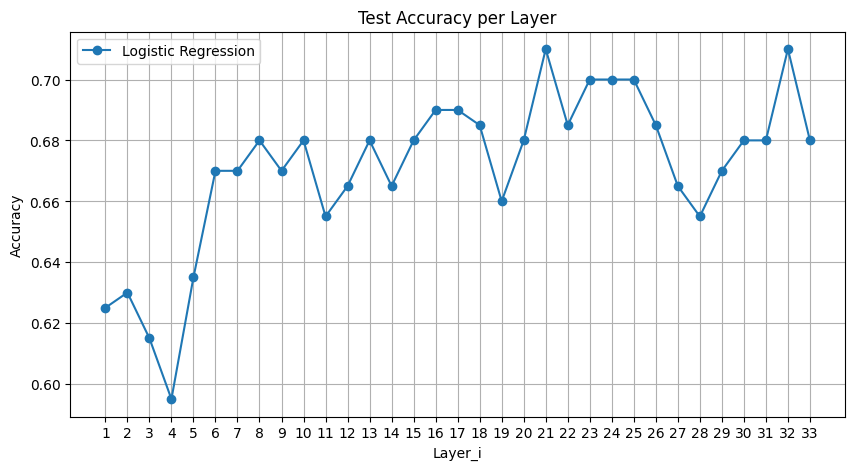

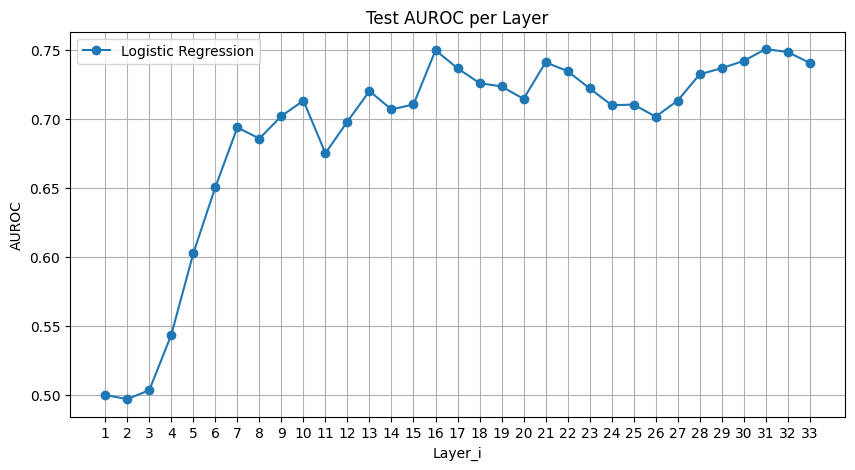

In [69]:
plot_1d_metrics([sablr_test_accs], ['Logistic Regression'], 'Accuracy')
plot_1d_metrics([sablr_test_aucs], ['Logistic Regression'], 'AUROC')

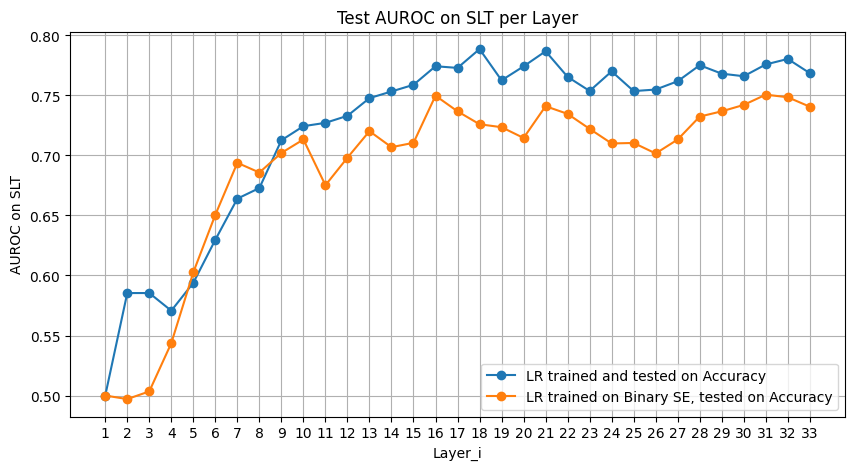

SLT: max AUROC for LR trained on Accuracy, tested on Accuracy: 0.7886 at 18 layer
SLT: max AUROC for LR trained on Binary SE, tested on Accuracy: 0.7506 at 31 layer


In [68]:
# Max AUROC achieved by 'transfer learning' compared to normal training
plot_1d_metrics([salr_test_aucs, sablr_test_aucs], ['LR trained and tested on Accuracy', 'LR trained on Binary SE, tested on Accuracy'], 'AUROC on SLT')
print(f"SLT: max AUROC for LR trained on Accuracy, tested on Accuracy: {max(salr_test_aucs):.4f} at {np.argmax(salr_test_aucs)+1} layer")
print(f"SLT: max AUROC for LR trained on Binary SE, tested on Accuracy: {max(sablr_test_aucs):.4f} at {np.argmax(sablr_test_aucs)+1} layer")

In [94]:
## Use trained probes on concat-ed inputs of best layers
topksablr_test_accs = {}
topksablr_test_aucs = {}

for indices in topksblr_models.keys():
    print(f"Testing on top-{len(indices)} SLT Datasets trained probe:", list(indices))
    _, _, X_test, _, _, y_test = concat_Xs_and_ys(list(indices), X_trains, X_vals, X_tests, y_trains, y_vals, y_tests)
    model = topksblr_models[indices]
    test_loss, test_acc, test_auc = sklearn_evaluate_on_test(model, X_test, y_test, binary_cls=True)
    topksablr_test_accs[tuple(indices)] = test_acc
    topksablr_test_aucs[tuple(indices)] = test_auc

# topksablr_test_aucs

Testing on top-1 SLT Datasets trained probe: [27]
Test Loss: 1.7433, Test Accuracy: 0.6550, AUROC: 0.7324
Testing on top-2 SLT Datasets trained probe: [27, 29]
Test Loss: 1.8131, Test Accuracy: 0.6650, AUROC: 0.7419
Testing on top-3 SLT Datasets trained probe: [27, 29, 30]
Test Loss: 2.0207, Test Accuracy: 0.6750, AUROC: 0.7493
Testing on top-4 SLT Datasets trained probe: [27, 29, 30, 28]
Test Loss: 2.0592, Test Accuracy: 0.6850, AUROC: 0.7482
Testing on top-5 SLT Datasets trained probe: [27, 29, 30, 28, 21]
Test Loss: 2.1678, Test Accuracy: 0.6850, AUROC: 0.7472
Testing on top-6 SLT Datasets trained probe: [27, 29, 30, 28, 21, 31]
Test Loss: 2.2046, Test Accuracy: 0.6800, AUROC: 0.7536
Testing on top-7 SLT Datasets trained probe: [27, 29, 30, 28, 21, 31, 20]
Test Loss: 2.1506, Test Accuracy: 0.6800, AUROC: 0.7536
Testing on top-8 SLT Datasets trained probe: [27, 29, 30, 28, 21, 31, 20, 15]
Test Loss: 2.1870, Test Accuracy: 0.6800, AUROC: 0.7535
Testing on top-9 SLT Datasets trained pr

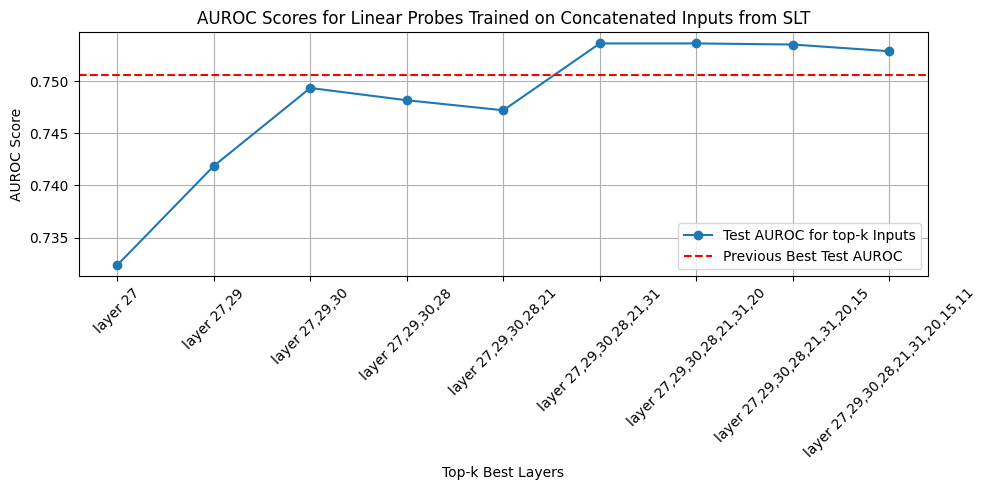

In [95]:
plot_metrics_w_constant(max(sablr_test_aucs), topksablr_test_aucs, 'SLT')

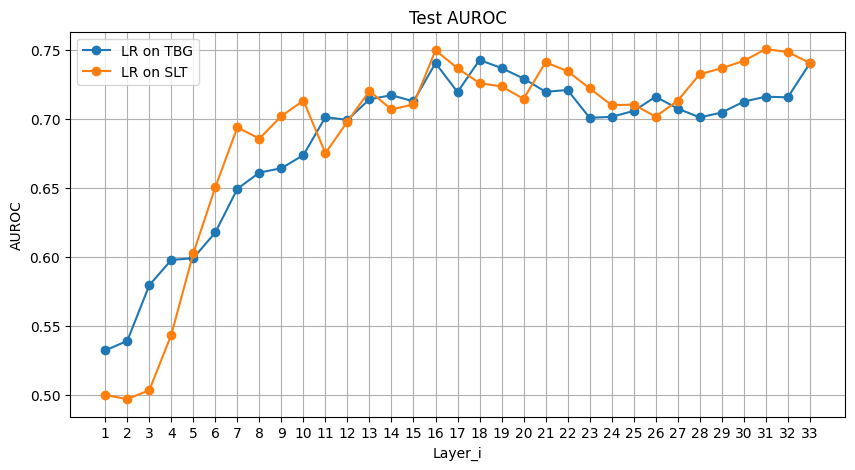

TBG: max AUROC for LR trained on b-SE and tested on Accuracy: 0.7427 at 18 layer
SLT: max AUROC for LR trained on b-SE and tested on Accuracy: 0.7506 at 31 layer


In [96]:
# Compare TBG and SLT at predicting Acc from probes trained on b-SE
plot_1d_metrics([tablr_test_aucs, sablr_test_aucs], ['LR on TBG', 'LR on SLT'], 'AUROC')
print(f"TBG: max AUROC for LR trained on b-SE and tested on Accuracy: {max(tablr_test_aucs):.4f} at {np.argmax(tablr_test_aucs)+1} layer")
print(f"SLT: max AUROC for LR trained on b-SE and tested on Accuracy: {max(sablr_test_aucs):.4f} at {np.argmax(sablr_test_aucs)+1} layer")